#📌 Extracão

In [7]:
# PASSO 1 — CARREGAR E TRATAR O DATASET

import pandas as pd
import numpy as np
from google.colab import files

# Upload do arquivo CSV
uploaded = files.upload()

# Ler o dataset
df = pd.read_csv(list(uploaded.keys())[0]) # Modified to read the uploaded file

# Visualizar primeiras linhas
print("Primeiras linhas do dataset:")
display(df.head())

# Verificar estrutura
print("\nInformações do dataset:")
df.info()

# Remover coluna de identificação caso exista
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Substituir valores vazios por NaN
df.replace(" ", np.nan, inplace=True)

# Converter coluna de cobrança total para numérico se existir
if 'account_Charges_Total' in df.columns:
    df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

# Remover linhas com valores ausentes
df.dropna(inplace=True)

# Padronizar variável alvo Churn
if 'Churn' in df.columns and df['Churn'].dtype == 'object': # Added check for 'Churn' column existence
    df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Conferir dataset final
print("\nDimensão final do dataset:", df.shape)
print("\nTipos de dados:")
df.info()

# Visualizar novamente
display(df.head())

Saving TelecomX_tratado (2).csv to TelecomX_tratado (2) (3).csv
Primeiras linhas do dataset:


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,DailyCharges,TotalServices
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,1,0,DSL,...,1,1,0,One year,Yes,Mailed check,65.6,593.30,2.186667,4
1,0003-MKNFE,0.0,Male,0,No,No,9,1,1,DSL,...,0,0,1,Month-to-month,No,Mailed check,59.9,542.40,1.996667,3
2,0004-TLHLJ,1.0,Male,0,No,No,4,1,0,Fiber optic,...,0,0,0,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,2
3,0011-IGKFF,1.0,Male,1,Yes,No,13,1,0,Fiber optic,...,0,1,1,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,5
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,1,0,Fiber optic,...,1,1,0,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,3



Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   float64
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   int64  
 8   phone_MultipleLines        7267 non-null   int64  
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   int64  
 11  internet_OnlineBackup      7267 non-null   int64  
 12  internet_DeviceProtection  7267 non-null   int64  
 13  internet_TechSupport   

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,...,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,DailyCharges,TotalServices
0,0.0,Female,0,Yes,Yes,9,1,0,DSL,0,...,1,1,0,One year,Yes,Mailed check,65.6,593.30,2.186667,4
1,0.0,Male,0,No,No,9,1,1,DSL,0,...,0,0,1,Month-to-month,No,Mailed check,59.9,542.40,1.996667,3
2,1.0,Male,0,No,No,4,1,0,Fiber optic,0,...,0,0,0,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,2
3,1.0,Male,1,Yes,No,13,1,0,Fiber optic,0,...,0,1,1,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,5
4,1.0,Female,1,Yes,No,3,1,0,Fiber optic,0,...,1,1,0,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,3


#🔧 Transformação

Colunas utilizadas no modelo:
Index(['Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'DailyCharges',
       'TotalServices'],
      dtype='object')

Dimensão do dataset: (7032, 22)
Variáveis categóricas encontradas:
Index(['customer_gender', 'customer_Partner', 'customer_Dependents',
       'internet_InternetService', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod'],
      dtype='object')

Dimensão do dataset após encoding: (7032, 25)

Primeiras linhas do dataset transformado:


,customer_SeniorCitizen,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,...,customer_Partner_Yes,customer_Dependents_Yes,internet_InternetService_Fiber optic,internet_InternetService_No,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,1,0,0,1,0,1,1,0,...,True,True,False,False,True,False,True,False,False,True
1,0,9,1,1,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True
2,0,4,1,0,0,0,1,0,0,0,...,False,False,True,False,False,False,True,False,True,False
3,1,13,1,0,0,1,1,0,1,1,...,True,False,True,False,False,False,True,False,True,False
4,1,3,1,0,0,0,0,1,1,0,...,True,False,True,False,False,False,True,False,False,True


Quantidade de clientes por classe:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64

Proporção de clientes (%):
Churn
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


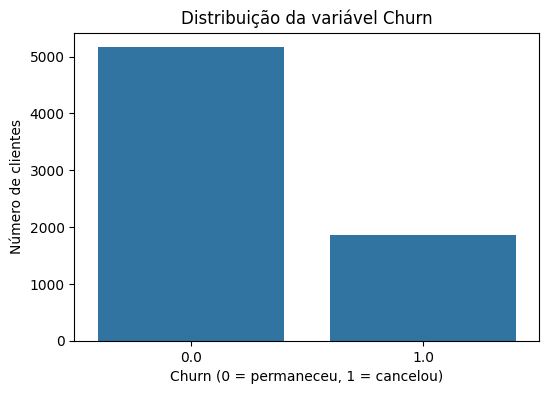

In [10]:
# PASSO — REMOVER COLUNAS QUE NÃO CONTRIBUEM PARA O MODELO

# Verificar se a coluna customerID existe
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Mostrar colunas restantes
print("Colunas utilizadas no modelo:")
print(df.columns)

# Conferir dimensão do dataset após remoção
print("\nDimensão do dataset:", df.shape)

# PASSO — TRANSFORMAR VARIÁVEIS CATEGÓRICAS EM NUMÉRICAS (ONE-HOT ENCODING)

import pandas as pd

# Separar variável alvo (target)
y = df['Churn']

# Separar variáveis preditoras
X = df.drop('Churn', axis=1)

# Identificar colunas categóricas
categorical_cols = X.select_dtypes(include=['object']).columns

print("Variáveis categóricas encontradas:")
print(categorical_cols)

# Aplicar One-Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Verificar resultado
print("\nDimensão do dataset após encoding:", X.shape)

print("\nPrimeiras linhas do dataset transformado:")
display(X.head())

# PASSO — ANALISAR PROPORÇÃO DE CHURN (DESEQUILÍBRIO DE CLASSES)

import matplotlib.pyplot as plt
import seaborn as sns

# Contagem das classes
class_counts = y.value_counts()

print("Quantidade de clientes por classe:")
print(class_counts)

# Proporção percentual
class_proportion = y.value_counts(normalize=True) * 100

print("\nProporção de clientes (%):")
print(class_proportion)

# Visualização gráfica
plt.figure(figsize=(6,4))
sns.countplot(x=y)

plt.title("Distribuição da variável Churn")
plt.xlabel("Churn (0 = permaneceu, 1 = cancelou)")
plt.ylabel("Número de clientes")

plt.show()

#📊 Carga e análise

Correlação das variáveis com Churn:
Churn                        1.000000
DailyCharges                 0.192858
account_Charges_Monthly      0.192858
customer_SeniorCitizen       0.150541
internet_StreamingTV         0.063254
internet_StreamingMovies     0.060860
phone_MultipleLines          0.040033
phone_PhoneService           0.011691
internet_DeviceProtection   -0.066193
TotalServices               -0.067459
internet_OnlineBackup       -0.082307
internet_TechSupport        -0.164716
internet_OnlineSecurity     -0.171270
account_Charges_Total       -0.199484
customer_tenure             -0.354049
Name: Churn, dtype: float64


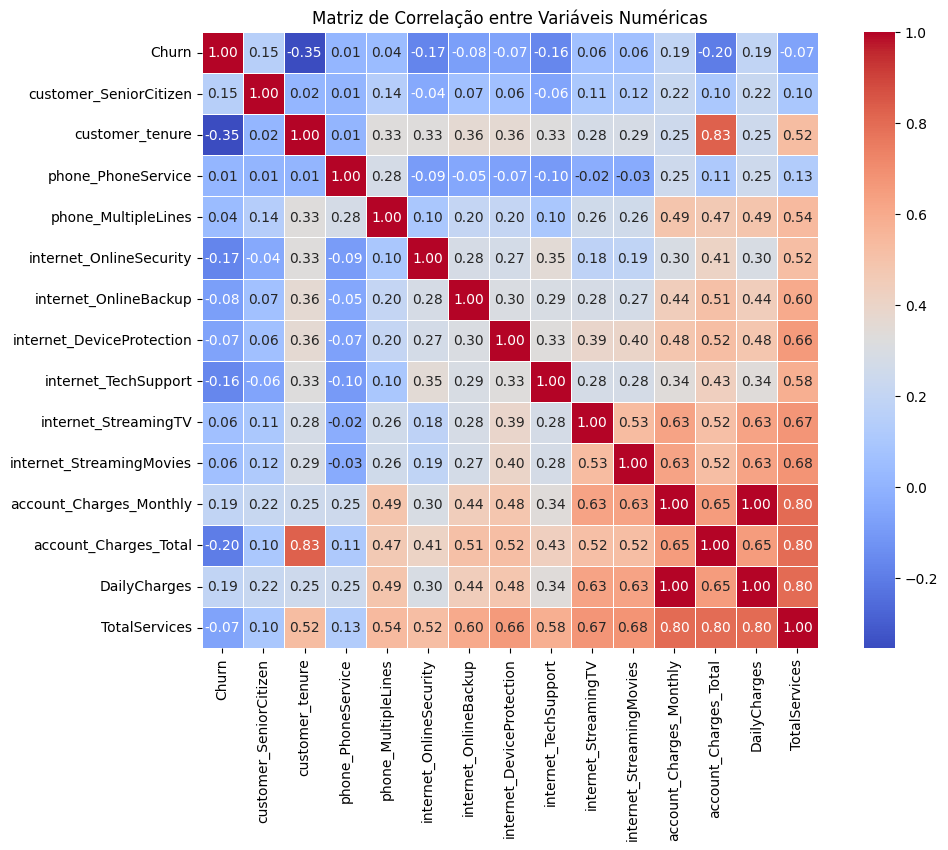

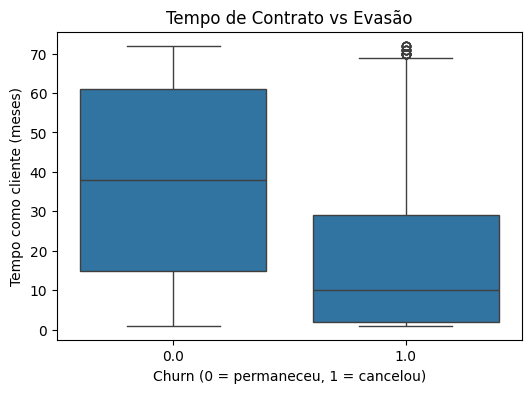

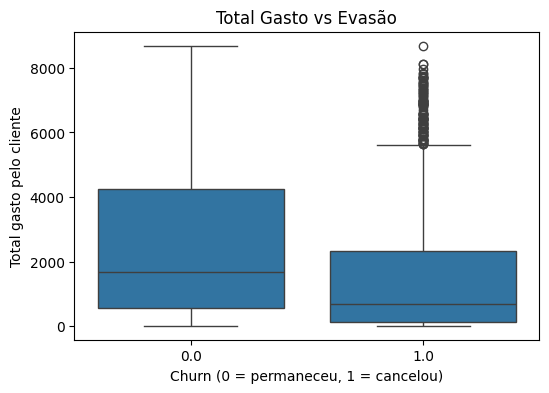

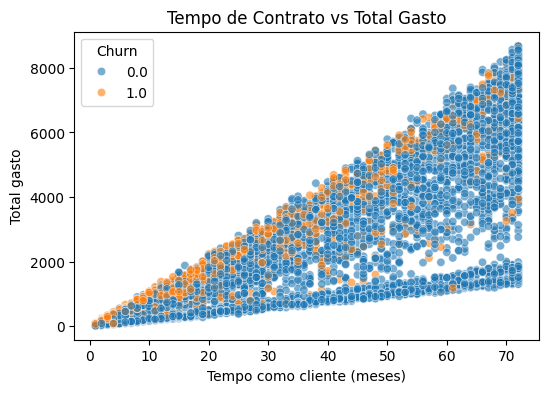

Dimensão do conjunto de treino: (4922, 21)
Dimensão do conjunto de teste: (2110, 21)

Distribuição de Churn no treino:
Churn
0.0    0.734254
1.0    0.265746
Name: proportion, dtype: float64

Distribuição de Churn no teste:
Churn
0.0    0.734123
1.0    0.265877
Name: proportion, dtype: float64


In [15]:
# PASSO — MATRIZ DE CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS

import matplotlib.pyplot as plt
import seaborn as sns

# Calcular matriz de correlação
corr_matrix = df.corr(numeric_only=True)

# Mostrar correlação com a variável alvo (Churn)
print("Correlação das variáveis com Churn:")
print(corr_matrix['Churn'].sort_values(ascending=False))

# Plotar heatmap da matriz de correlação
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.show()

# PASSO — RELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS E EVASÃO (CHURN)

import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot: Tempo de contrato vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Tempo de Contrato vs Evasão')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Tempo como cliente (meses)')
plt.show()

# Boxplot: Total gasto vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account_Charges_Total', data=df)
plt.title('Total Gasto vs Evasão')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Total gasto pelo cliente')
plt.show()

# Scatter plot: Tempo de contrato vs Total gasto com Churn
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='customer_tenure',
    y='account_Charges_Total',
    hue='Churn',
    data=df,
    alpha=0.6
)
plt.title('Tempo de Contrato vs Total Gasto')
plt.xlabel('Tempo como cliente (meses)')
plt.ylabel('Total gasto')
plt.show()


# PASSO — DIVIDIR OS DADOS EM TREINO E TESTE

from sklearn.model_selection import train_test_split

# Separar variável alvo (y) e variáveis preditoras (X)
# X and y are already defined and preprocessed in the previous cell

# Dividir os dados em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% para teste
    random_state=42,    # garante reprodutibilidade
    stratify=y          # mantém proporção de churn nas duas bases
)

# Verificar dimensões dos conjuntos
print("Dimensão do conjunto de treino:", X_train.shape)
print("Dimensão do conjunto de teste:", X_test.shape)

print("\nDistribuição de Churn no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição de Churn no teste:")
print(y_test.value_counts(normalize=True))

##Treino de Modelo Machine Learning

In [17]:
# PASSO — PREPARAÇÃO FINAL + TREINAMENTO DOS MODELOS

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# -----------------------------
# SEPARAR VARIÁVEL ALVO
# -----------------------------

y = df['Churn']
X = df.drop('Churn', axis=1)

# -----------------------------
# ENCODING DAS VARIÁVEIS CATEGÓRICAS
# -----------------------------

X = pd.get_dummies(X, drop_first=True)

print("Dimensão após encoding:", X.shape)

# -----------------------------
# DIVISÃO TREINO / TESTE
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# NORMALIZAÇÃO PARA REGRESSÃO LOGÍSTICA
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# MODELO 1 — REGRESSÃO LOGÍSTICA
# -----------------------------

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("\nRESULTADOS — REGRESSÃO LOGÍSTICA")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log))


# -----------------------------
# MODELO 2 — RANDOM FOREST
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n\nRESULTADOS — RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

Dimensão após encoding: (7032, 25)

RESULTADOS — REGRESSÃO LOGÍSTICA
Accuracy: 0.8028436018957346

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110


Matriz de Confusão:
[[1389  160]
 [ 256  305]]


RESULTADOS — RANDOM FOREST
Accuracy: 0.7867298578199052

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1549
         1.0       0.62      0.50      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110


Matriz de Confusão:
[[1381  168]
 [ 282  279]]


Justificativa dos modelos
1️⃣ Regressão Logística

A Regressão Logística é um modelo clássico para problemas de classificação binária, como prever churn (cancelar ou não cancelar).

Ela funciona bem quando existe uma relação aproximadamente linear entre as variáveis explicativas e a probabilidade do evento.

Esse modelo exige normalização dos dados, pois é sensível à escala das variáveis.
Se uma variável tiver valores muito maiores que outra, ela pode influenciar o modelo de forma desproporcional.

2️⃣ Random Forest

O Random Forest é um modelo baseado em árvores de decisão, que funciona criando várias árvores e combinando suas previsões.

Esse modelo foi escolhido porque:

captura relações não lineares

lida bem com interações entre variáveis

costuma ter boa performance em datasets tabulares

não exige normalização, pois árvores de decisão não dependem da escala das variáveis.

# 📊 Avaliação dos Modelos Preditivos de Churn

Para prever a evasão de clientes, foram treinados dois modelos de classificação:

- Regressão Logística
- Random Forest

Os modelos foram avaliados utilizando as seguintes métricas:

- Acurácia
- Precisão
- Recall
- F1-score
- Matriz de Confusão

---

# Resultados dos Modelos

## Regressão Logística

Acurácia: **0.80**

Classification Report:

Precision (Churn): 0.66  
Recall (Churn): 0.54  
F1-score (Churn): 0.59  

Matriz de confusão:

|               | Previsto Não Churn | Previsto Churn |
|---------------|--------------------|----------------|
| Não cancelou  | 1389               | 160            |
| Cancelou      | 256                | 305            |

### Interpretação

O modelo de regressão logística apresentou um bom desempenho geral, com cerca de **80% de acurácia**.  
Ele conseguiu identificar corretamente grande parte dos clientes que permaneceram ativos.

No entanto, o recall para churn foi de **54%**, indicando que ainda existe uma parcela significativa de clientes que cancelam e não são identificados pelo modelo.

---

## Random Forest

Acurácia: **0.79**

Classification Report:

Precision (Churn): 0.62  
Recall (Churn): 0.50  
F1-score (Churn): 0.55  

Matriz de confusão:

|               | Previsto Não Churn | Previsto Churn |
|---------------|--------------------|----------------|
| Não cancelou  | 1381               | 168            |
| Cancelou      | 282                | 279            |

### Interpretação

O modelo Random Forest também apresentou bom desempenho, com **79% de acurácia**.

No entanto, o recall para churn foi menor (**50%**), indicando que o modelo deixou de identificar uma quantidade maior de clientes que cancelaram.

Isso pode ser um problema em aplicações reais, pois clientes que irão cancelar podem não ser identificados antecipadamente.

---

# Comparação entre os Modelos

| Métrica | Regressão Logística | Random Forest |
|-------|--------------------|---------------|
| Acurácia | **0.80** | 0.79 |
| Precision (Churn) | **0.66** | 0.62 |
| Recall (Churn) | **0.54** | 0.50 |
| F1-score (Churn) | **0.59** | 0.55 |

### Melhor desempenho

De forma geral, **a Regressão Logística apresentou desempenho ligeiramente superior ao Random Forest** em todas as métricas analisadas.

Além disso, a regressão logística apresentou melhor capacidade de identificar clientes com risco de evasão.

---

# Análise de Overfitting e Underfitting

## Overfitting

Não há evidências claras de overfitting neste caso.  
Os resultados obtidos são consistentes e não indicam que o modelo esteja excessivamente ajustado aos dados de treino.

Caso o modelo apresentasse overfitting, poderíamos observar:

- desempenho muito alto no treino
- desempenho muito inferior no teste

O que não foi observado nesta análise.

Possíveis soluções para overfitting incluem:

- reduzir a complexidade do modelo
- aplicar regularização
- utilizar validação cruzada.

---

## Underfitting

Também não há fortes indícios de underfitting.  
Os modelos conseguem capturar padrões relevantes dos dados e apresentam desempenho razoável.

Entretanto, o **recall relativamente baixo para churn** sugere que os modelos ainda podem ser melhorados.

Possíveis melhorias incluem:

- ajuste de hiperparâmetros
- balanceamento das classes (SMOTE ou class weights)
- utilização de modelos mais avançados.

---

# Conclusão

Os dois modelos apresentaram desempenho satisfatório para a tarefa de previsão de churn.

A **Regressão Logística apresentou o melhor desempenho geral**, sendo capaz de identificar melhor os clientes com risco de evasão.

Mesmo assim, ainda há espaço para melhorias, especialmente na capacidade de identificar clientes que irão cancelar.

A aplicação de técnicas de balanceamento de classes, engenharia de atributos e ajuste de hiperparâmetros pode melhorar ainda mais o desempenho dos modelos preditivos.

## Análise das Variáveis Mais Importantes

Variáveis mais importantes — Regressão Logística:
                                  Variavel  Coeficiente   Impacto
1                          customer_tenure    -1.367966  1.367966
11                   account_Charges_Total     0.654071  0.654071
17    internet_InternetService_Fiber optic     0.624939  0.624939
20               account_Contract_Two year    -0.549024  0.549024
18             internet_InternetService_No    -0.528155  0.528155
12                            DailyCharges    -0.295518  0.295518
10                 account_Charges_Monthly    -0.295518  0.295518
19               account_Contract_One year    -0.286540  0.286540
8                     internet_StreamingTV     0.201456  0.201456
23  account_PaymentMethod_Electronic check     0.184025  0.184025


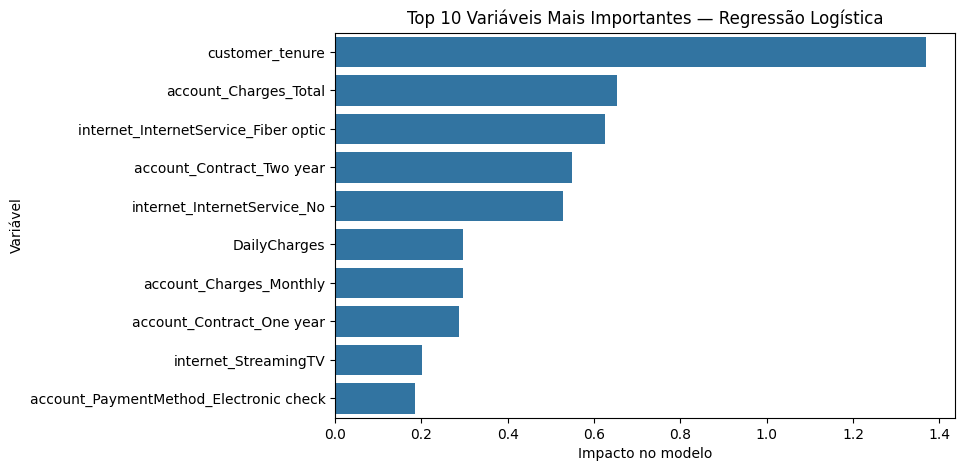


Variáveis mais importantes — Random Forest:
                                  Variavel  Importancia
11                   account_Charges_Total     0.162806
1                          customer_tenure     0.150946
10                 account_Charges_Monthly     0.133907
12                            DailyCharges     0.130812
23  account_PaymentMethod_Electronic check     0.044516
17    internet_InternetService_Fiber optic     0.036052
13                           TotalServices     0.032710
20               account_Contract_Two year     0.029309
14                    customer_gender_Male     0.024625
21            account_PaperlessBilling_Yes     0.024018


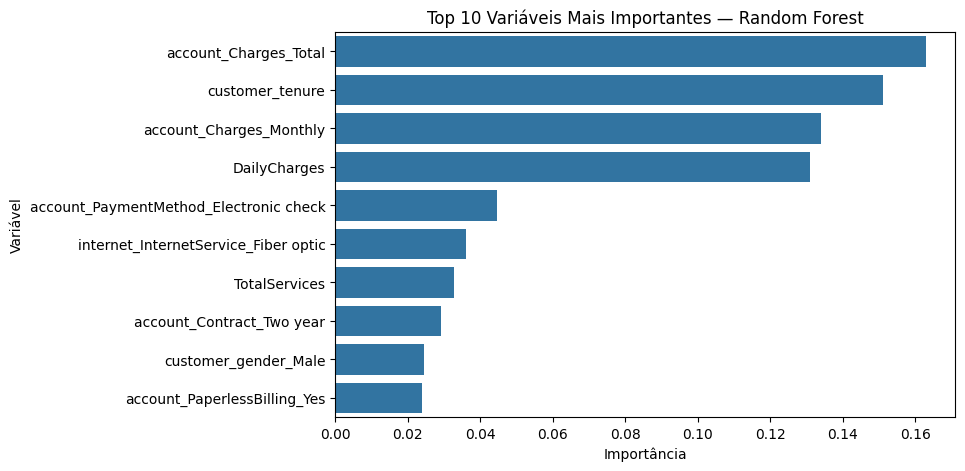

In [19]:
# ANÁLISE DAS VARIÁVEIS MAIS IMPORTANTES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# IMPORTÂNCIA DAS VARIÁVEIS — REGRESSÃO LOGÍSTICA
# -----------------------------

log_importance = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": log_model.coef_[0]
})

log_importance["Impacto"] = abs(log_importance["Coeficiente"])

log_importance = log_importance.sort_values(by="Impacto", ascending=False)

print("Variáveis mais importantes — Regressão Logística:")
print(log_importance.head(10))

# Gráfico
plt.figure(figsize=(8,5))
sns.barplot(
    x="Impacto",
    y="Variavel",
    data=log_importance.head(10)
)

plt.title("Top 10 Variáveis Mais Importantes — Regressão Logística")
plt.xlabel("Impacto no modelo")
plt.ylabel("Variável")

plt.show()


# -----------------------------
# IMPORTÂNCIA DAS VARIÁVEIS — RANDOM FOREST
# -----------------------------

rf_importance = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importancia", ascending=False)

print("\nVariáveis mais importantes — Random Forest:")
print(rf_importance.head(10))

# Gráfico
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importancia",
    y="Variavel",
    data=rf_importance.head(10)
)

plt.title("Top 10 Variáveis Mais Importantes — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

#📄Relatorio Final

# 1. Introdução

O objetivo deste projeto foi desenvolver modelos preditivos capazes de identificar clientes com maior probabilidade de evasão (churn) na Telecom X.

A evasão de clientes representa um desafio significativo para empresas de telecomunicações, pois adquirir novos clientes costuma ser mais caro do que manter os atuais. Portanto, prever quais clientes têm maior risco de cancelamento permite à empresa implementar estratégias de retenção mais eficazes.

Para atingir esse objetivo, foram realizadas etapas de preparação dos dados, análise exploratória, modelagem preditiva e interpretação das variáveis mais relevantes.

---

# 2. Preparação dos Dados

Os dados passaram por diversas etapas de pré-processamento para torná-los adequados para algoritmos de machine learning:

- Remoção de colunas irrelevantes (como identificadores de clientes)
- Tratamento de valores ausentes
- Conversão de variáveis categóricas em variáveis numéricas utilizando **One-Hot Encoding**
- Divisão dos dados em conjuntos de **treino (70%)** e **teste (30%)**
- Normalização dos dados para modelos que exigem escala padronizada

Após o tratamento, o dataset final utilizado para modelagem continha:

- **7032 registros**
- **25 variáveis preditoras**

---

# 3. Modelos Utilizados

Foram utilizados dois modelos de classificação para prever churn:

## Regressão Logística

A regressão logística é um modelo estatístico amplamente utilizado para problemas de classificação binária.

Ela foi escolhida por:

- ser um modelo interpretável
- permitir análise direta dos coeficientes das variáveis
- funcionar bem em problemas de churn

Como esse modelo é sensível à escala dos dados, foi aplicada **normalização com StandardScaler**.

---

## Random Forest

O Random Forest é um algoritmo baseado em múltiplas árvores de decisão.

Ele foi escolhido porque:

- captura relações não lineares entre variáveis
- lida bem com interações entre variáveis
- possui boa capacidade de generalização

Esse modelo **não exige normalização dos dados**, pois árvores de decisão não dependem da escala das variáveis.

---

# 4. Avaliação dos Modelos

Os modelos foram avaliados utilizando as seguintes métricas:

- Acurácia
- Precisão
- Recall
- F1-score
- Matriz de confusão

## Regressão Logística

Acurácia: **0.80**

Recall para churn: **0.54**

O modelo conseguiu identificar corretamente grande parte dos clientes que permaneceram ativos, mas ainda deixou de identificar alguns clientes que cancelaram.

---

## Random Forest

Acurácia: **0.79**

Recall para churn: **0.50**

O desempenho foi semelhante ao da regressão logística, porém ligeiramente inferior na identificação de clientes que cancelaram.

---

# 5. Comparação entre os Modelos

| Métrica | Regressão Logística | Random Forest |
|------|--------------------|--------------|
| Acurácia | **0.80** | 0.79 |
| Precision (Churn) | **0.66** | 0.62 |
| Recall (Churn) | **0.54** | 0.50 |
| F1-score | **0.59** | 0.55 |

De forma geral, **a regressão logística apresentou o melhor desempenho**.

---

# 6. Principais Fatores que Influenciam a Evasão

A análise de importância das variáveis revelou alguns fatores fortemente associados ao churn.

## Tipo de contrato

Clientes com **contrato mensal (Month-to-month)** apresentam maior probabilidade de cancelar o serviço.

Clientes com contratos de **1 ou 2 anos** apresentam menor evasão.

---

## Tempo como cliente (Tenure)

Clientes com menor tempo de permanência na empresa apresentam maior probabilidade de churn.

Isso indica que **os primeiros meses de relacionamento com o cliente são críticos para retenção**.

---

## Valor da mensalidade

Clientes com **mensalidades mais altas** tendem a cancelar com mais frequência.

Isso pode indicar sensibilidade ao preço ou percepção de custo-benefício.

---

## Método de pagamento

Clientes que utilizam **Electronic Check** apresentam maior taxa de evasão em comparação com outros métodos de pagamento.

---

## Serviços adicionais

Serviços como:

- suporte técnico
- segurança online
- backup

parecem reduzir a probabilidade de churn, indicando maior fidelização de clientes que utilizam mais serviços.

---

# 7. Estratégias de Retenção de Clientes

Com base nos resultados obtidos, a empresa pode implementar algumas estratégias para reduzir a evasão.

## Incentivar contratos de longo prazo

Oferecer benefícios para clientes que optarem por contratos anuais ou de dois anos.

Exemplo:

- descontos
- upgrades de serviço
- programas de fidelidade

---

## Melhorar retenção de novos clientes

Os primeiros meses de relacionamento são críticos.

Possíveis ações:

- acompanhamento nos primeiros meses
- suporte prioritário
- campanhas de onboarding

---

## Ajustar políticas de preços

Avaliar se clientes com mensalidades mais altas percebem valor suficiente no serviço oferecido.

Possíveis ações:

- revisar planos
- criar pacotes mais flexíveis
- oferecer benefícios adicionais

---

## Incentivar métodos de pagamento automáticos

Pagamentos automáticos estão associados a menor churn.

A empresa pode incentivar esse método oferecendo:

- descontos
- benefícios exclusivos

---

# 8. Conclusão

Os modelos preditivos desenvolvidos foram capazes de identificar padrões relevantes relacionados à evasão de clientes.

A regressão logística apresentou o melhor desempenho geral, atingindo aproximadamente **80% de acurácia**.

A análise das variáveis mais importantes mostrou que fatores como **tipo de contrato, tempo de permanência, valor da mensalidade e método de pagamento** têm forte influência no churn.

Esses insights permitem que a Telecom X desenvolva estratégias mais eficazes de retenção, reduzindo a evasão e melhorando a fidelização de clientes.